In [59]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
import os
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import pickle
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover
import matplotlib
from matplotlib.lines import Line2D

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
 
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/' # for latex, you might need to change this


#print(os.environ['PATH'])# = os.environ['PATH'] + 'c:/Library/TeX/texbin/' # for latex, you might need to change this
label_size = 8
# plt.style.use('fivethirtyeight')
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r'\usepackage{dsfont}\usepackage{amsmath}\usepackage{physics}')
#matplotlib.rcParams['text.latex.preamble']=[r'/usepackage{dsfont}/usepackage{amsmath}/usepackage{physics}']
 
pr ={"axes.labelsize": 8,               # LaTeX default is 10pt font.
     'axes.titlesize': 8,               
    "font.size": 8,
    "legend.fontsize": 8,               # Make the legend/label fonts
    "xtick.labelsize": 8,               # a little smaller
    "ytick.labelsize": 8,
    'figure.figsize': (1.8 * 3.35, 3* 9 * 3.35 / 16), #2.0476
    "errorbar.capsize": 1.5,
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots
    "font.sans-serif": [],    
    }
for k, v in pr.items():
    matplotlib.rcParams[k] = v
   
matplotlib.rcParams["font.family"] = "serif"
# mpl.rcParams["font.serif"] = ["STIX"]
matplotlib.rcParams["mathtext.fontset"] = "stix"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
with open(f'../data/nodes_{50}_reg_{3}_graph_{0}_opt_SGD_lr_{0.0001}_v2.pkl', 'rb') as file:
    data = pickle.load(file)   

In [28]:
data['transition_states']['p=1']['losses']


KeyError: 'losses'

### Energies


#### Linear Scale

In [9]:
def get_results(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    energies_list=[]

    for graph in graphs:
        #print(n)
        with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
            data = pickle.load(file)   
        energy = data[initialization][f'p={p}']['energy']
        energies_list.append(energy)    
    
    return np.mean(energies_list), np.std(energies_list)

In [29]:
def get_initial_results(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    losses_list=[]

    for graph in graphs:
        #print(n)
        try:
            with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
                data = pickle.load(file) 
            loss = data[initialization][f'p={p}']['losses'][0]  
            losses_list.append(loss)    
        except:
            losses_list.append(0)
    
    return np.mean(losses_list), np.std(losses_list)

### n=50

{'random_init': [9.914342156856334, 10.179828617679757, 54.81583575485584, 83.97680509180924, 123.0641733054083, 92.5258348735168, 105.80551596650206, 112.46062782011047, 96.15900396720915, 88.73166225423067, 60.29514653671961], 'transition_states': [114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274], 'fixed_angles_optimization': [-73.26649709948232, -68.7815041135539, -24.887819402891957, -20.678670834193284, 33.403223802733024, 33.40322380285595, 33.40074653249924, 33.10405682837661, 33.39586596275949, 33.27257727765661, 30.16815988230296], 'interpolation': [114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274]}
[8.193279873009837, -7.639112710247311, -0.

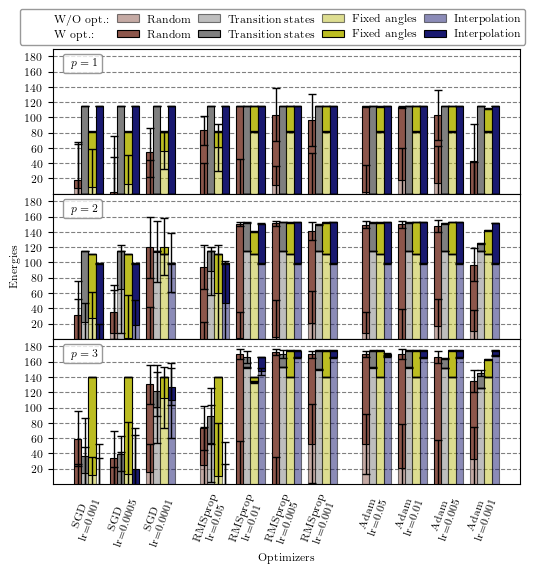

In [96]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 200
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

if n ==50:
    major_yticks_pos = [10, 20, 30, 40, 50]
elif n==100:
    major_yticks_pos = [10, 20, 30, 40, 50, 60, 70, 80]
elif n==150:
    major_yticks_pos = [20, 40, 60, 80, 100, 120, 140]
elif n==200:
    major_yticks_pos = [20, 40, 60, 80, 100, 120, 140, 160, 180]


major_yticks_names = major_yticks_pos




fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    initial_data_dic = {f'{name}': [] for name in initializations} 
    error_dic = {f'{name}': [] for name in initializations}
    initial_error_dic = {f'{name}': [] for name in initializations}

    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    
                    
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    initial_mean, initial_error = get_initial_results(optimizer, p, initialization, learning_rate, n)

                    data_dic[str(initialization)].append(-(mean-initial_mean))
                    error_dic[str(initialization)].append(error)
    
                    labels.append(f'{optimizer}\nlr={learning_rate}')

                    initial_mean, initial_error = get_initial_results(optimizer, p, initialization, learning_rate, n)
                    initial_data_dic[str(initialization)].append(-initial_mean)
                    initial_error_dic[str(initialization)].append(initial_error)


    print(data_dic)

    plot, = axs[p-1].plot([0], [0], linestyle='dashed', linewidth=1, color='w')
    plot, = axs[p-1].plot([0], [0], linestyle='dashed', linewidth=1, color='w')

    
    for attribute, measurement in data_dic.items():
        bottom = np.zeros(11)
        offset = width * multiplier
    
        initial_values = initial_data_dic[attribute]
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], initial_values, width, edgecolor = 'black', linewidth=0.8, yerr = initial_error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=0.5, label=f'{attribute}', bottom = bottom)
        bottom = initial_values
        
        print(bottom)
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3),color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = bottom)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=49)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=140)
    elif n ==200:
        ax.set_ylim(bottom=0., top=190)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['W/O opt.:', 'W opt.:', 'Random', 'Random', 'Transition states', 'Transition states', 'Fixed angles', 'Fixed angles', 'Interpolation', 'Interpolation'], bbox_to_anchor=(0.47, 3.15), loc = 'center', ncols = 5, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)

fig.savefig(f'../results/MAXCUT_energies_all_initializations_nodes_{n}.pdf', dpi=300, bbox_inches='tight')

    
plt.show()

sgd 0.0001 fixed, interpol
rms prop 0.005 fixed, interpol
adam 0.05, fixed, interp

#### n = 100

{'random_init': [-8.739468557878746, 5.484091182300483, 51.49944719827165, 35.6552225555025, 57.136055603339585, 45.759150342956715, 45.22307790008832, 57.03839654426357, 57.03584501792413, 54.067446275790225, 19.26463612552008], 'transition_states': [57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216], 'fixed_angles_optimization': [0.4267598493894639, -4.3909275489381, 57.17409887568516, 37.90020564767561, 57.174098875629205, 57.17409887568516, 57.17296691229562, 57.028735752695766, 57.1688169755284, 57.11137007930525, 55.607684627247465], 'interpolation': [57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216, 57.173547179895216]}
{'random_init': [7.9836319141230545, 14.915450

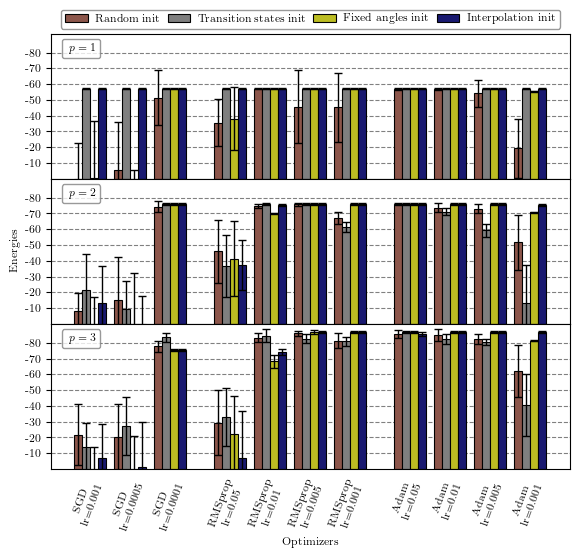

In [221]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 100
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan', 'lawngreen', 'crimson']
width = 0.2
multiplier = 0

major_yticks_pos = [10, 20, 30, 40, 50, 60, 70, 80]
major_yticks_names = [-10, -20, -30, -40, -50, -60, -70, -80]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Fixed angles init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

#### n = 150

{'random_init': [-1.1321585746451135, -4.6831044929920775, 83.52340993513907, 60.70652597814252, 86.06644951470255, 68.87874524581339, 49.77689228131972, 86.00913988623964, 85.67784594299768, 65.77062275709211, 52.920725093130685], 'transition_states': [86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083], 'fixed_angles_optimization': [23.183705446136397, -5.0877904059033, 86.15646985256373, 58.59029018989916, 86.17098284962887, 86.17098284971668, 86.16911799070022, 85.94637934896478, 86.1655605800548, 86.07284146207886, 83.74144807329063], 'interpolation': [86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083, 86.17019003981083]}
{'random_init': [8.003414201079172, 25.20889463060588, 79.60056484947

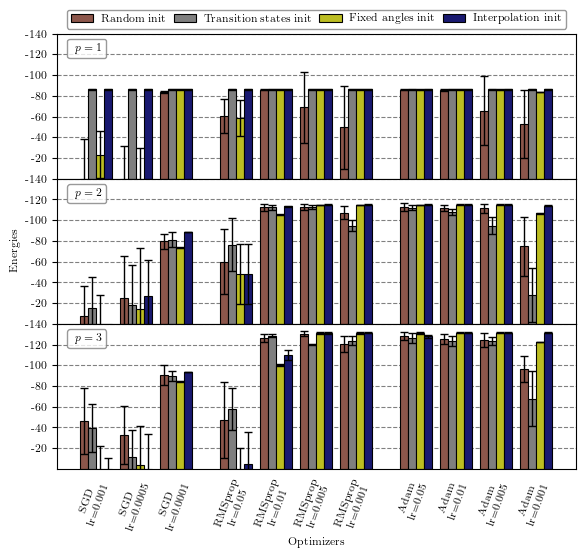

In [235]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 150
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [20, 40, 60, 80, 100, 120, 140]
major_yticks_names = [-20, -40, -60, -80, -100, -120, -140]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=140)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Fixed angles init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

#### n = 200

{'random_init': [18.10762202986617, 2.540715907432446, 54.0498374627409, 82.87172028735245, 114.83444784655251, 103.39070544263468, 97.05660864079157, 114.58192653874906, 114.0106457349403, 103.3163254821969, 42.248601680519116], 'transition_states': [114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274], 'fixed_angles_optimization': [8.202999452879622, 12.68799243880805, 56.58167714946999, 60.79082571816866, 114.87272035509497, 114.8727203552179, 114.87024308486119, 114.57355338073856, 114.86536251512143, 114.74207383001855, 111.6376564346649], 'interpolation': [114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274, 114.87167741633274]}
{'random_init': [31.365869165329997, 35.114

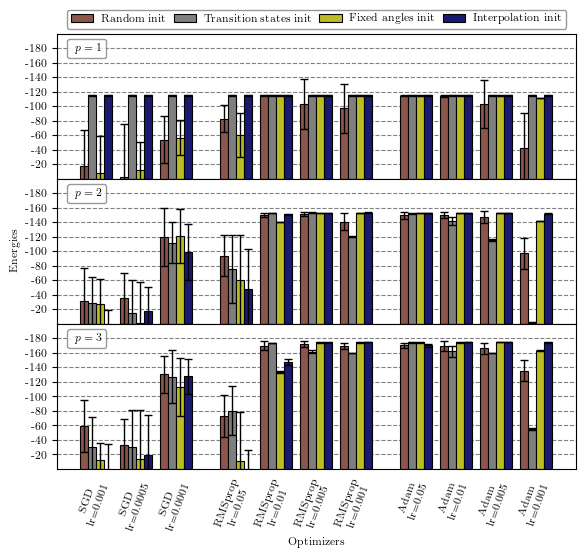

In [239]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 200
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [20, 40, 60, 80, 100, 120, 140, 160, 180]
major_yticks_names = [-20, -40, -60, -80, -100, -120, -140, -160, -180]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean)
                    error_dic[str(initialization)].append(error)
      
                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00000001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    #ax.set_yscale('logit')
    #ax1.gca()
    #ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0., top=92)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    #ax.set_yticks(major_yticks_pos, major_yticks_names)
    #ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Fixed angles init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

#### Log Scale

In [240]:
def get_results(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    energies_list=[]

    for graph in graphs:
        #print(n)
        with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
            data = pickle.load(file)   
        energy = data[initialization][f'p={p}']['energy']
        if energy>=-1:
            energy = -1.001
        energies_list.append(energy)    
    
    return np.mean(energies_list), np.std(energies_list)

{'random_init': [0.10119548790172057, 0.15796793708734677, 0.5159954719827166, 0.35755322555511365, 0.5713605560333959, 0.45959350342961597, 0.45260375316481755, 0.5703839654426357, 0.5703584501792414, 0.5406744627579022, 0.19733735047224849], 'transition_states': [0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521], 'fixed_angles_optimization': [0.15782394811894193, 0.013796083548481932, 0.5717409887568516, 0.38100405647675606, 0.5717409887562921, 0.5717409887568516, 0.5717296691229562, 0.5702873575269577, 0.571688169755284, 0.5711137007930526, 0.5560768462724747], 'interpolation': [0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521, 0.5717354717989521]}




{'random_init': 

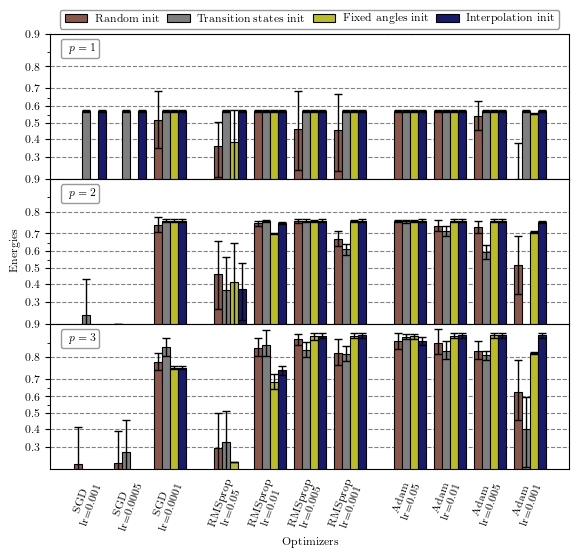

In [242]:
optimizers = ['SGD', 'RMSprop', 'Adam']
ps = [1, 2, 3]
n = 100
initializations = ['random_init', 'transition_states', 'fixed_angles_optimization', 'interpolation']

colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']
width = 0.2
multiplier = 0

major_yticks_pos = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
major_yticks_names = [-10, -20, -30, -40, -50, -60, -70, -80, -90, -100, -110, -120, -130, -140, -150]


major_yticks_pos = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
major_yticks_names = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
major_yticks_names_2 = [None for _ in range(len(major_yticks_pos))]
minor_yticks_pos = [0.55, 0.6, 0.65, 0.7, 0.8, 0.85]
minor_ticks_names = [None for _ in range(len(minor_yticks_pos))]


fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)

for p in ps:
    multiplier = 0
    data_dic = {f'{name}': [] for name in initializations}
    error_dic = {f'{name}': [] for name in initializations}
    for initialization in initializations:
        labels = []

        for optimizer in optimizers:
                if optimizer == 'SGD':
                    learning_rates = [0.001, 0.0005, 0.0001]
                elif optimizer == 'RMSprop':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]
                elif optimizer == 'Adam':
                    learning_rates = [0.05, 0.01, 0.005, 0.001]

                for learning_rate in learning_rates:
                    mean, error = get_results(optimizer, p, initialization, learning_rate, n)
                    data_dic[str(initialization)].append(-mean/n)
                    if (-mean-error) >=1:
                        error_dic[str(initialization)].append(error/n)
                    else:
                        error_dic[str(initialization)].append(0.000001)

                    labels.append(f'{optimizer}\nlr={learning_rate}')
    print(data_dic)

    for key, item in data_dic.items():
        print()
    for attribute, measurement in data_dic.items():
        offset = width * multiplier
        rects = axs[p-1].bar([0+ offset, 1+ offset, 2+ offset, 3.5+ offset, 4.5+ offset, 5.5+ offset, 6.5+ offset, 8+ offset, 9+ offset, 10+ offset, 11+ offset], measurement, width, edgecolor = 'black', linewidth=0.8, yerr = error_dic[attribute], error_kw=dict(lw=1, ecolor='black', capthick=1, capsize = 3), color=colors[6+multiplier], alpha=1, label=f'{attribute}', bottom = 0.00001)
        multiplier += 1

for ax in axs:
    ax.label_outer()
    ax.set_xlabel('Optimizers')
    ax.set_yscale('logit')
    #ax1.gca()
    ax.yaxis.set_ticklabels([])
    ax.set_yticks(major_yticks_pos, major_yticks_names)
    if n ==50:
        ax.set_ylim(bottom=0., top=50)
    elif n ==100:
        ax.set_ylim(bottom=0.2, top=0.900001)
    elif n ==150:
        ax.set_ylim(bottom=0., top=150)
    elif n ==200:
        ax.set_ylim(bottom=0., top=200)

    ax.set_yticks(major_yticks_pos, major_yticks_names)
    ax.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)
    ax.set_axisbelow(True)
    ax.yaxis.grid(color='gray', linestyle='dashed')

axs[1].set_ylabel('Energies', y = 0.5)
axs[2].set_xticks([0+ width, 1+ width, 2+ width, 3.5+ width, 4.5+ width, 5.5+ width, 6.5+ width, 8+ width, 9+ width, 10+ width, 11+ width], labels, rotation=70)
axs[2].tick_params(bottom = False)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]

axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)
plt.legend(labels = ['Random init', 'Transition states init', 'Fixed angles init', 'Interpolation init'], bbox_to_anchor=(0.5, 3.1), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)


    
plt.show()

### Losses

In [11]:
def get_losses(optimizer, p, initialization, learning_rate, n):
    graphs=[i for i in range(10)]
    regularity = 3
    losses_list=[]

    try:
        for graph in graphs:
            #print(n)
            with open(f'../data/nodes_{n}_reg_{regularity}_graph_{graph}_opt_{optimizer}_lr_{learning_rate}_v2.pkl', 'rb') as file:
                data = pickle.load(file)   
            losses = data[initialization][f'p={p}']['losses']
            losses_list.append(losses)   

        arrays = [np.array(x) for x in losses_list] 
        mean = [np.mean(k) for k in zip(*arrays)]
        error = [np.std(k) for k in zip(*arrays)]
    
        return mean, error
    except:
        return [], []


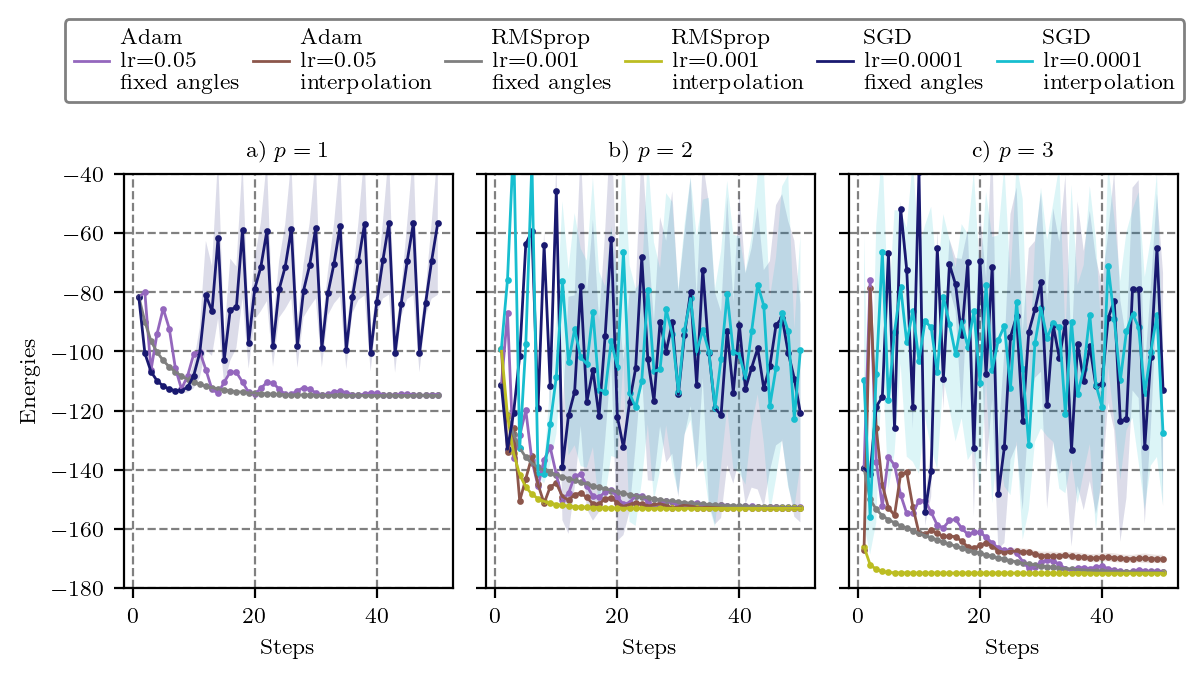

In [100]:
n=200
ps = [1, 2, 3]
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan']

labels = []
arguments = [
            #[0.01, 'Adam', 'fixed_angles_optimization'],
            #[0.0001, 'SGD', 'fixed_angles'], 
            #[0.05, 'Adam', 'random_init'],
            [0.05, 'Adam', 'fixed_angles_optimization'], 
            [0.05, 'Adam', 'interpolation'], 
            [0.001, 'RMSprop', 'fixed_angles_optimization'], 
            [0.001, 'RMSprop', 'interpolation'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.01, 'RMSprop', 'transition_states'],
            [0.0001, 'SGD', 'fixed_angles_optimization'], 
            #[0.0001, 'SGD', 'random_init'], 
            #[0.0001, 'SGD', 'transition_states'],
            [0.0001, 'SGD', 'interpolation'],
            ]
fig, axs = plt.subplots(1, 3, dpi=200, layout='tight', figsize=(1.8 * 3.35, 1.5* 9 * 3.35 / 16))
for p in ps:
    for idx, argument in enumerate(arguments):
        if argument[2] == 'random_init':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nrandom')
        elif argument[2] == 'transition_states':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ntransition')
        elif argument[2] == 'fixed_angles_optimization':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nfixed angles')
        elif argument[2] == 'interpolation':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ninterpolation')
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        # for index, max in enumerate(error_max):
        #     if max>1:
        #         error_max[index] = 0.99999
        axs[p-1].fill_between(range(1, len(mean)+1), error_min, error_max, alpha = 0.15, color = colors[idx+5], edgecolor = None)

for p in ps:
    for idx, argument in enumerate(arguments):
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        axs[p-1].scatter(range(1, len(mean)+1), mean, s=2, label='_nolegend_', color=colors[idx+5])
        axs[p-1].plot(range(1, len(mean)+1), mean, linestyle='solid', linewidth=1, label=labels[idx], color=colors[idx+5])
        
        axs[p-1].set_xlabel('Steps')
        axs[p-1].set_axisbelow(True)
        axs[p-1].yaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].xaxis.grid(color='gray', linestyle='dashed')

        if n==50:
            axs[p-1].set_ylim(bottom=-45, top=-15)
        elif n==100:
            axs[p-1].set_ylim(bottom=-90, top=-40)
        elif n==150:
            axs[p-1].set_ylim(bottom=-140, top=-40)
        elif n==200:
            axs[p-1].set_ylim(bottom=-180, top=-40)

        

axs[1].set_yticklabels([])
axs[2].set_yticklabels([])


axs[0].set_ylabel('Energies')
axs[0].set_title('a) $p = 1$', loc='center')
axs[1].set_title('b) $p = 2$', loc='center')
axs[2].set_title('c) $p = 3$', loc='center')

plt.tight_layout()
axs[1].legend(loc='upper center', ncols=6, bbox_to_anchor=(0.42, 1.4), fancybox=True, edgecolor = 'grey', columnspacing = 0.6, handletextpad = 0.5, handlelength=1.6, framealpha=1, facecolor=None)
fig.savefig(f'../results/MAXCUT_losses_initializations_nodes_{n}.pdf', dpi=300, bbox_inches='tight')


#ax1.set_yscale('logit')
#ax1.yaxis.set_ticklabels([])
#ax1.set_ylim(bottom=0.79, top=0.9997)
#ax1.set_yticks(major_yticks_pos, major_yticks_names)
#ax1.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)


plt.show()

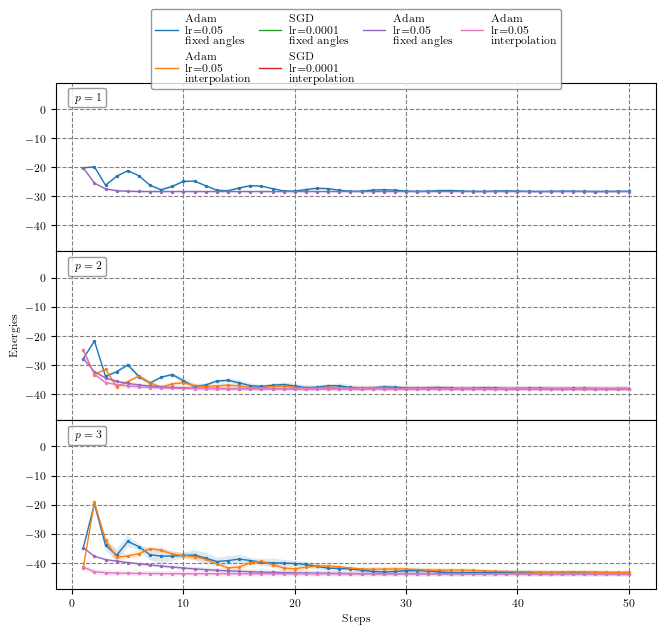

In [274]:
n=50
ps = [1, 2, 3]
labels = []
arguments = [
            #[0.01, 'Adam', 'fixed_angles_optimization'],
            #[0.0001, 'SGD', 'fixed_angles'], 
            #[0.05, 'Adam', 'random_init'],
            [0.05, 'Adam', 'fixed_angles_optimization'], 
            [0.05, 'Adam', 'interpolation'], 
            #[0.001, 'RMSprop', 'fixed_angles_optimization'], 
            [0.005, 'RMSprop', 'fixed_angles'], 
            [0.005, 'RMSprop', 'fixed_angles'], 
            #[0.01, 'RMSprop', 'transition_states'],
            [0.0001, 'SGD', 'fixed_angles_optimization'], 
            #[0.0001, 'SGD', 'random_init'], 
            #[0.0001, 'SGD', 'transition_states'],
            [0.0001, 'SGD', 'interpolation'],
            ]

fig = plt.figure()
gs = fig.add_gridspec(3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)
for p in ps:
    for idx, argument in enumerate(arguments):
        if argument[2] == 'random_init':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nrandom')
        elif argument[2] == 'transition_states':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ntransition')
        elif argument[2] == 'fixed_angles_optimization':
            labels.append(f'{argument[1]}\nlr={argument[0]}\nfixed angles')
        elif argument[2] == 'interpolation':
            labels.append(f'{argument[1]}\nlr={argument[0]}\ninterpolation')
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        
        error_min = [i-j for i,j in zip(mean, error)]
        error_max = [i+j for i, j in zip(mean, error)]
        # for index, max in enumerate(error_max):
        #     if max>1:
        #         error_max[index] = 0.99999
        axs[p-1].fill_between(range(1, len(mean)+1), error_min, error_max, alpha = 0.15, color = colors[idx], label = '_nolegend_', edgecolor = None)

for p in ps:
    for idx, argument in enumerate(arguments):
        mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
        axs[p-1].scatter(range(1, len(mean)+1), mean, s=2, label='_nolegend_', color=colors[idx])
        axs[p-1].plot(range(1, len(mean)+1), mean, linestyle='solid', linewidth=1, label=labels[idx], color=colors[idx])
        
        ##axs[p-1].set_ylabel('Energies')
        axs[p-1].set_axisbelow(True)
        axs[p-1].yaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].xaxis.grid(color='gray', linestyle='dashed')
        axs[p-1].set_ylim(bottom=-49, top=9)
        axs[p-1].label_outer()
        


axs[1].set_ylabel('Energies', y = 0.5)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
axs[2].add_artist(l1)


axs[2].set_xlabel('Steps')
# axs[0].set_title('a) $p = 1$', loc='center')
# axs[1].set_title('b) $p = 2$', loc='center')
# axs[2].set_title('c) $p = 3$', loc='center')

plt.tight_layout()

plt.legend(labels = labels, bbox_to_anchor=(0.5, 3.2), loc = 'center', ncols = 4, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)

#axs[0].legend(loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.6), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)


#ax1.set_yscale('logit')
#ax1.yaxis.set_ticklabels([])
#ax1.set_ylim(bottom=0.79, top=0.9997)
#ax1.set_yticks(major_yticks_pos, major_yticks_names)
#ax1.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)


plt.show()

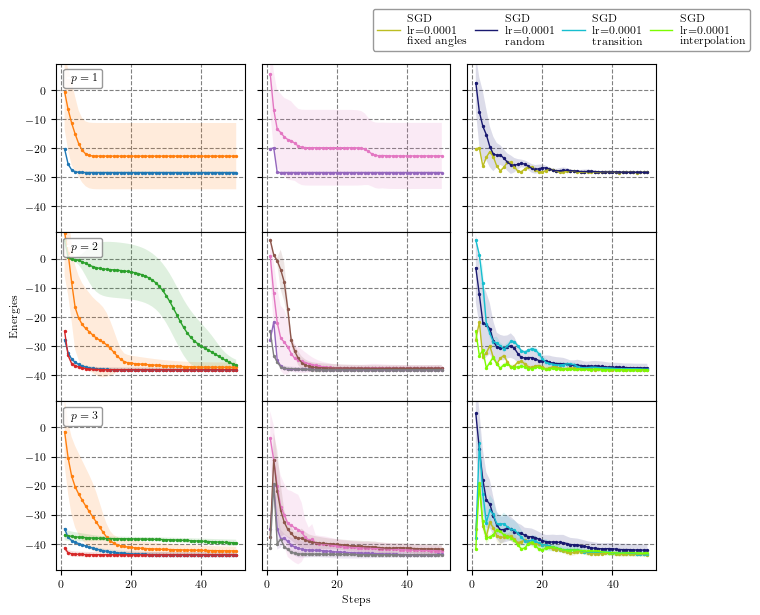

In [306]:
n=50
ps = [1, 2, 3]
labels = []
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'midnightblue', 'tab:cyan', 'lawngreen', 'crimson']

arguments = [
             [[0.0001, 'SGD', 'fixed_angles_optimization'], 
            [0.0001, 'SGD', 'random_init'], 
            [0.0001, 'SGD', 'transition_states'],
            [0.0001, 'SGD', 'interpolation']],

            [[0.005, 'RMSprop', 'fixed_angles_optimization'], 
            [0.005, 'RMSprop', 'random_init'], 
            [0.005, 'RMSprop', 'transition_states'],
            [0.005, 'RMSprop', 'interpolation']],

            [[0.05, 'Adam', 'fixed_angles_optimization'], 
            [0.05, 'Adam', 'random_init'], 
            [0.05, 'Adam', 'transition_states'],
            [0.05, 'Adam', 'interpolation']]

            #[0.01, 'Adam', 'fixed_angles_optimization'],
            #[0.0001, 'SGD', 'fixed_angles'], 
            #[0.05, 'Adam', 'random_init'],
            #[0.05, 'Adam', 'fixed_angles_optimization'], 
            #[0.05, 'Adam', 'interpolation'], 
            #[0.001, 'RMSprop', 'fixed_angles_optimization'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.005, 'RMSprop', 'fixed_angles'], 
            #[0.01, 'RMSprop', 'transition_states'],
            #[0.0001, 'SGD', 'fixed_angles_optimization'], 
            #[0.0001, 'SGD', 'random_init'], 
            #[0.0001, 'SGD', 'transition_states'],
            #[0.0001, 'SGD', 'interpolation'],
            ]

fig = plt.figure()
gs = fig.add_gridspec(3, 3, hspace=0)
axs = gs.subplots(sharex=True, sharey=True)
for p in ps:
    labels = []
    counter = 0
    for column in [0, 1, 2]:
        for idx, argument in enumerate(arguments[column]):
            if argument[2] == 'random_init':
                labels.append(f'{argument[1]}\nlr={argument[0]}\nrandom')
            elif argument[2] == 'transition_states':
                labels.append(f'{argument[1]}\nlr={argument[0]}\ntransition')
            elif argument[2] == 'fixed_angles_optimization':
                labels.append(f'{argument[1]}\nlr={argument[0]}\nfixed angles')
            elif argument[2] == 'interpolation':
                labels.append(f'{argument[1]}\nlr={argument[0]}\ninterpolation')
            mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
            
            error_min = [i-j for i,j in zip(mean, error)]
            error_max = [i+j for i, j in zip(mean, error)]
            # for index, max in enumerate(error_max):
            #     if max>1:
            #         error_max[index] = 0.99999
            axs[p-1][column].fill_between(range(1, len(mean)+1), error_min, error_max, alpha = 0.15, color = colors[counter], label = '_nolegend_', edgecolor = None)
            counter +=1
for p in ps:
    counter = 0
    for column in [0, 1, 2]:
        for idx, argument in enumerate(arguments[column]):
            mean, error = get_losses(argument[1], p, argument[2], argument[0], n)
            axs[p-1][column].scatter(range(1, len(mean)+1), mean, s=2, label='_nolegend_', color=colors[counter])
            axs[p-1][column].plot(range(1, len(mean)+1), mean, linestyle='solid', linewidth=1, label=labels[counter], color=colors[counter])
            
            ##axs[p-1].set_ylabel('Energies')
            axs[p-1][column].set_axisbelow(True)
            axs[p-1][column].yaxis.grid(color='gray', linestyle='dashed')
            axs[p-1][column].xaxis.grid(color='gray', linestyle='dashed')
            axs[p-1][column].set_ylim(bottom=-49, top=9)
            axs[p-1][column].label_outer()
            counter +=1
        


axs[1][0].set_ylabel('Energies', y = 0.5)

legend_element = [Line2D([0], [0], marker='.', color='w', label='$p = 1$',
                          markerfacecolor='g', markersize=0)]
axs[0][0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=2$',
                          markerfacecolor='g', markersize=0)]
axs[1][0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))
legend_element = [Line2D([0], [0], marker='.', color='w', label='$p=3$',
                          markerfacecolor='g', markersize=0)]
axs[2][0].legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc='upper left', bbox_to_anchor=(0.01, 1.))

#l1 = plt.legend(handles=legend_element, edgecolor = 'grey', facecolor=(1, 1, 1, 1), handletextpad=-1.8, loc = 'upper left', fancybox=True, bbox_to_anchor=(0.01, 1.))
#axs[2][0].add_artist(l1)


axs[2][1].set_xlabel('Steps')
# axs[0].set_title('a) $p = 1$', loc='center')
# axs[1].set_title('b) $p = 2$', loc='center')
# axs[2].set_title('c) $p = 3$', loc='center')

plt.tight_layout()
plt.legend(labels = labels, bbox_to_anchor=(0.5, 3.2), loc = 'center', ncols = 8, edgecolor = 'grey', facecolor='white', columnspacing = 0.7, handletextpad = 0.7)

#axs[0].legend(loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.6), fancybox=True, edgecolor = 'grey', framealpha=1, facecolor=None)


#ax1.set_yscale('logit')
#ax1.yaxis.set_ticklabels([])
#ax1.set_ylim(bottom=0.79, top=0.9997)
#ax1.set_yticks(major_yticks_pos, major_yticks_names)
#ax1.set_yticks(minor_yticks_pos, minor_ticks_names, minor=True)


plt.show()